In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('./DATASET.csv')
print(df.head())

    Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No         0.0      Graduate            No   
1  LP001003   Male     Yes         1.0      Graduate            No   
2  LP001005   Male     Yes         0.0      Graduate           Yes   
3  LP001006   Male     Yes         0.0  Not Graduate            No   
4  LP001008   Male      No         0.0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [32]:
mean_dependent = df['Dependents'].mean()
df['Dependents'].fillna(mean_dependent, inplace=True)
mean_loan_amount = df['LoanAmount'].mean()
df['LoanAmount'].fillna(mean_loan_amount, inplace=True)

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         598 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         598 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


C:\Users\USER\AppData\Local\Temp\ipykernel_12912\1982237516.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(mean_dependent, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_12912\1982237516.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

<BarContainer object of 598 artists>

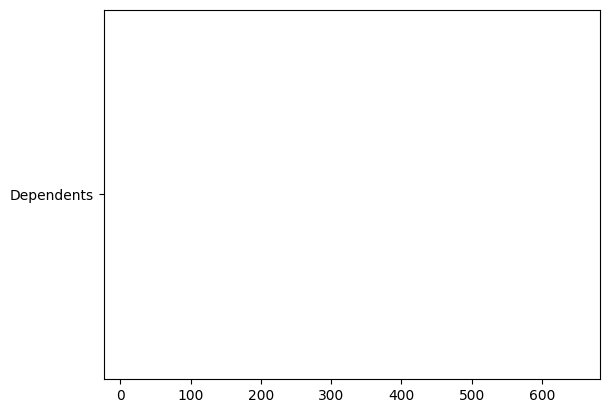

In [33]:
plt.bar (df['LoanAmount'],['Dependents']) 

              LoanAmount
Education               
Graduate      152.151749
Not Graduate  119.855501


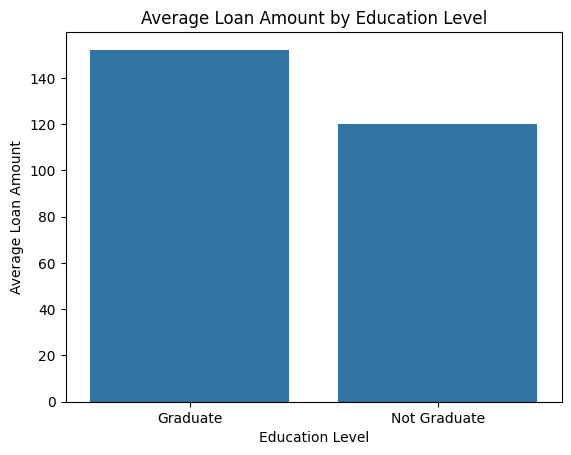

In [34]:
# creat a pivot table with average loan amount by education level
pivot_table = df.pivot_table(index='Education', values='LoanAmount', aggfunc='mean')
print(pivot_table)
plt.Figure(figsize=(10,6))

#Heatmap
sns.barplot(x=pivot_table.index, y=pivot_table['LoanAmount'])

#Add labels and title
plt.title('Average Loan Amount by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Loan Amount')

# Show the plot
plt.show()

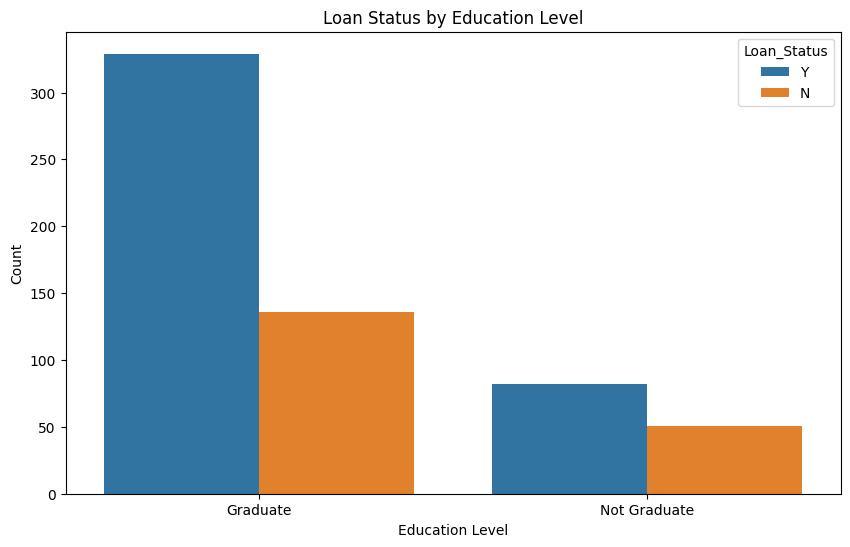

In [35]:
plt.figure(figsize=(10,6))

#scatter plot
sns.countplot(x='Education', hue='Loan_Status', data=df)

#Add labels and title
plt.title('Loan Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')

# Show the plot
plt.show()


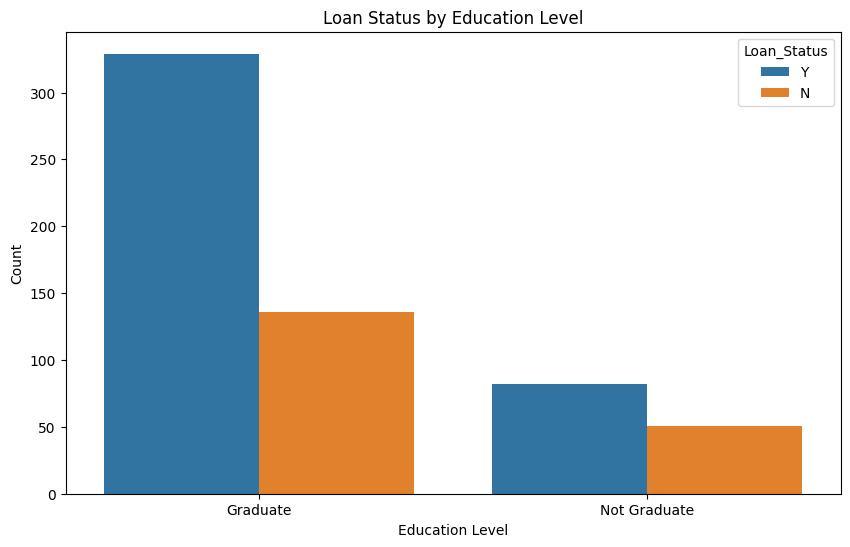

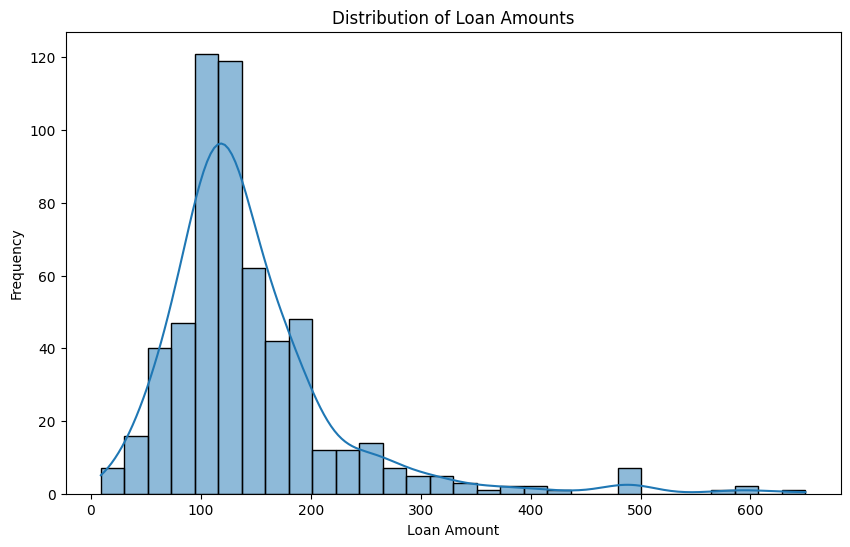

In [6]:
plt.figure(figsize=(10,6))

#scatter plot
sns.countplot(x='Education', hue='Loan_Status', data=df)

#Add labels and title
plt.title('Loan Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')

# Show the plot
plt.show()


#Histogram
plt.figure(figsize=(10,6))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()


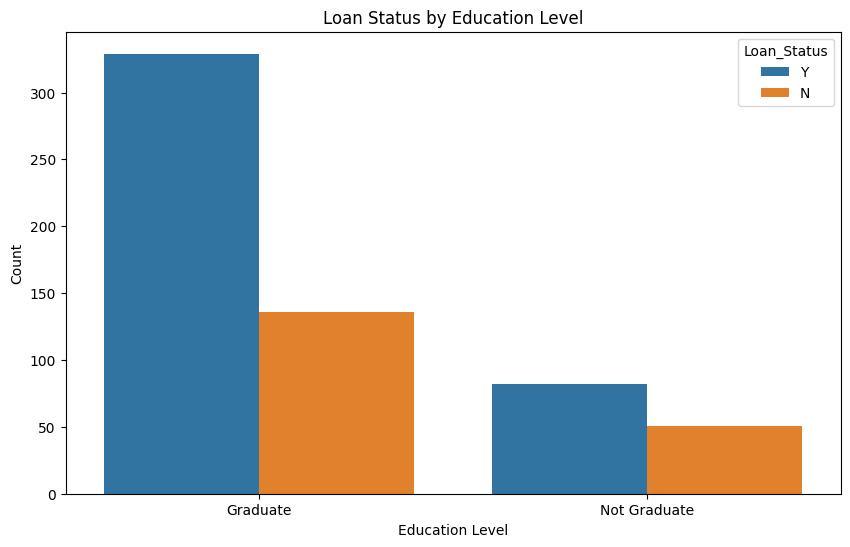

<Axes: >

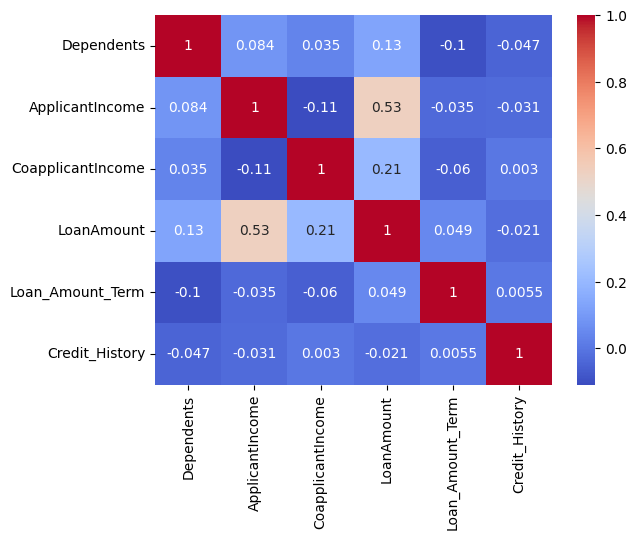

In [7]:
plt.figure(figsize=(10,6))

#scatter plot
sns.countplot(x='Education', hue='Loan_Status', data=df)

#Add labels and title
plt.title('Loan Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')

# Show the plot
plt.show()



# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

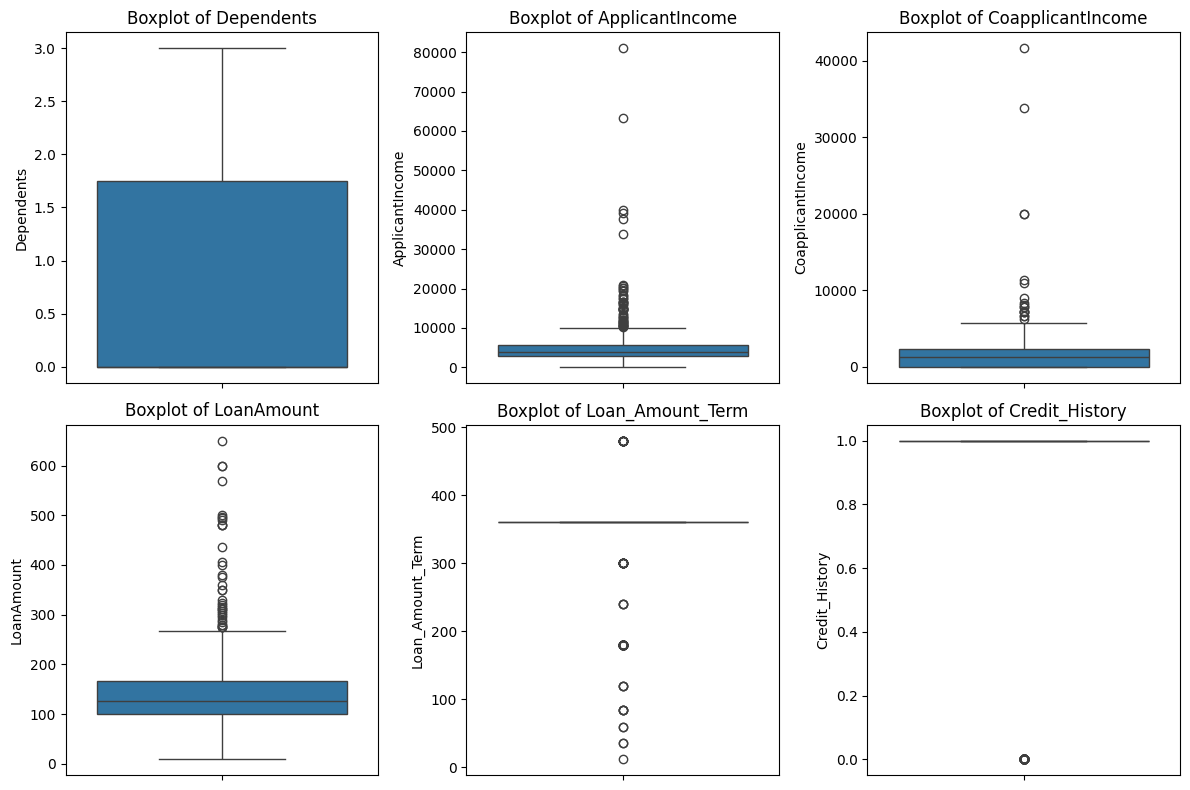

In [8]:
# Plot boxplot for numeric columns
plt.figure(figsize=(12,8))

for i, column in enumerate(numeric_df.columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=numeric_df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()





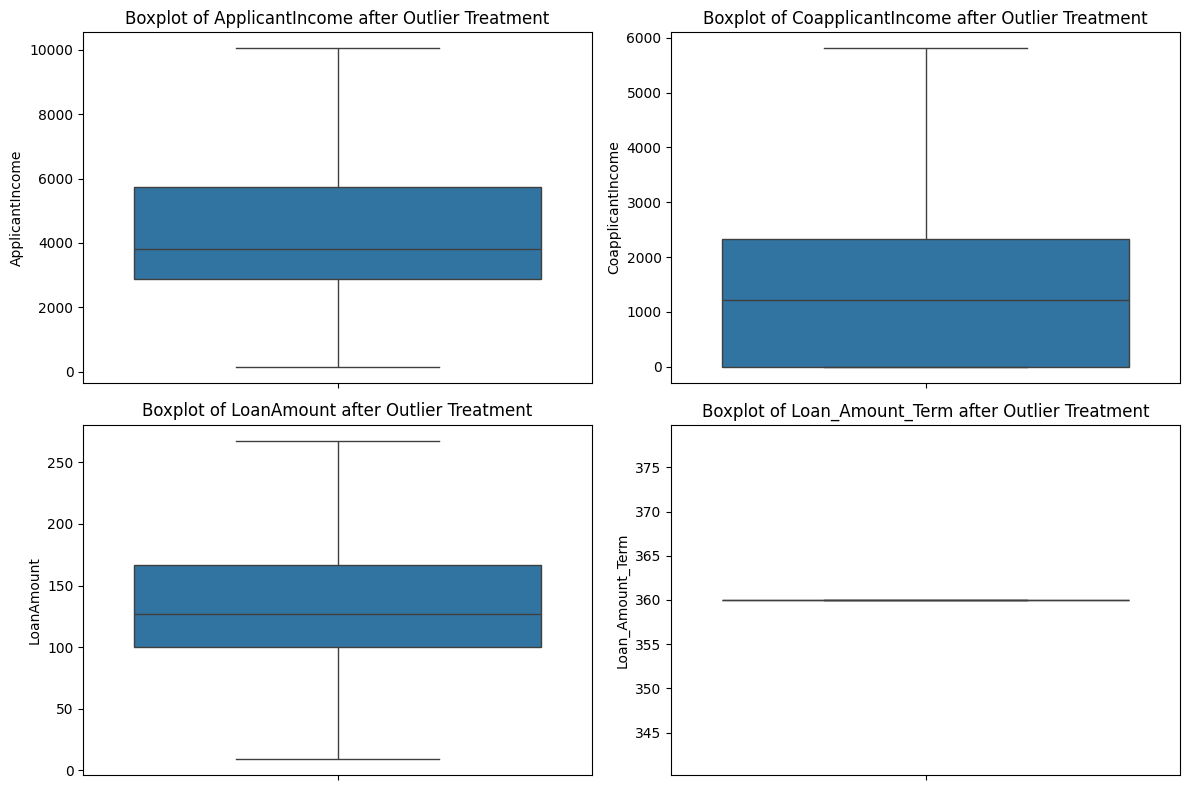

In [9]:
# Function to fix outliers using IQR method
def fix_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.where(data[column] < lower_bound, lower_bound,
                            np.where(data[column] > upper_bound, upper_bound, data[column]))
    return data

# Fix outliers for specific columns
columns_to_fix = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
for col in columns_to_fix:
    df = fix_outliers_iqr(df, col)

# Plot boxplot for specific columns after outlier treatment
plt.figure(figsize=(12,8))
for i, column in enumerate(columns_to_fix, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column} after Outlier Treatment')
plt.tight_layout()
plt.show()

In [40]:
#creat a subplot layout for aech column
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         598 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    float64
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         598 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(6), object(7)
memory usage: 60.9+ KB


In [10]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849.0,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
##segregate the dependent and independent variables
X = df.drop('Loan_Status', axis=1)  
y = df['Loan_Status']


%pip install scikit-learn

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


((478, 12), (120, 12))

In [11]:
df.columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [45]:
X = X.drop(columns=[col for col in X.columns if col.startswith("Loan_ID_")])


In [14]:
X = X.fillna(0)


In [15]:
print(X.dtypes)


Loan_ID               object
Gender                object
Married               object
Dependents           float64
Education             object
Self_Employed         object
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object


In [16]:
# List of numeric columns you want to convert
numeric_cols = ['Dependents', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Fill NaNs if needed (e.g., with 0 or median)
X[numeric_cols] = X[numeric_cols].fillna(0).astype(int)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [19]:
print(X_train.dtypes)


Loan_ID               object
Gender                object
Married               object
Dependents           float64
Education             object
Self_Employed         object
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object


In [20]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [21]:
# Convert all columns to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Handle missing values
X = X.fillna(0)

# Split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale properly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [22]:
from sklearn.linear_model import LogisticRegression


In [23]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
# Evaluate the model
y_pred = model.predict(X_test)

In [26]:
# calulate accuracy
accuracy = (y_test == y_pred).mean()
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.80


In [27]:
from sklearn.metrics import confusion_matrix


In [28]:
# confusion matrix
Conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(Conf_matrix)


Confusion Matrix:
[[17 18]
 [ 6 79]]


In [29]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

print(cm_df)


          Predicted 0  Predicted 1
Actual 0           17           18
Actual 1            6           79


In [30]:
from sklearn.metrics import classification_report

# Use a different variable name
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

           N       0.74      0.49      0.59        35
           Y       0.81      0.93      0.87        85

    accuracy                           0.80       120
   macro avg       0.78      0.71      0.73       120
weighted avg       0.79      0.80      0.79       120



In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Parameter grid
param_grid = {
    'penalty': ['l1', 'l2'],
    'C'      : np.logspace(-4, 4, 20),
    'solver' : ['liblinear', 'lbfgs']
}




In [33]:
logreg = LogisticRegression()
clf = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy')
clf.fit(X_train, y_train)


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [35]:
clf.best_params_

{'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'liblinear'}

In [36]:
clf.best_score_

np.float64(0.7615570175438597)

In [37]:
clf.best_index_

np.int64(2)

In [38]:
clf.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0.0001)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred_optimized = clf.predict(X_test)

In [40]:
conf_mat = confusion_matrix(y_test, y_pred_optimized)
print("Confusion Matrix after Hyperparameter Tuning:")
print(conf_mat)

Confusion Matrix after Hyperparameter Tuning:
[[17 18]
 [ 6 79]]


In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy=accuracy_score(y_test, y_pred_optimized)
print(f'Optimized Accuracy: {accuracy:.2f}')


Optimized Accuracy: 0.80


In [42]:
true_positives = conf_mat[0, 0]
false_positives = conf_mat[0, 0]
false_negatives = conf_mat[1, 0]
true_negatives = conf_mat[1, 1] 


In [43]:
Accuracy = (true_positives + true_negatives) / (true_positives + false_positives + false_negatives + true_negatives)
Accuracy = (true_positives + true_negatives) / (true_positives + false_positives + false_negatives + true_negatives)

In [44]:
presion = true_positives / (true_positives + false_positives)
presion

np.float64(0.5)

In [45]:
Recall = true_positives / (true_positives + false_negatives)
Recall

np.float64(0.7391304347826086)

In [46]:
f1_score = 2 * (presion * Recall) / (presion + Recall)
f1_score

np.float64(0.5964912280701754)

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier  # or your trained model
import pickle

In [48]:
numeric_features = ['Dependents','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
categorical_features = ['Gender','Married','Education','Self_Employed','Property_Area']

In [50]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])


In [51]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())  # replace with your trained model
])

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import pickle



In [53]:
df = pd.read_csv('DATASET.csv') 
print("Dataset loaded. Shape:", df.shape)
print(df.head())

Dataset loaded. Shape: (598, 13)
    Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No         0.0      Graduate            No   
1  LP001003   Male     Yes         1.0      Graduate            No   
2  LP001005   Male     Yes         0.0      Graduate           Yes   
3  LP001006   Male     Yes         0.0  Not Graduate            No   
4  LP001008   Male      No         0.0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         R

In [54]:
df['Dependents'].fillna(0, inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(1, inplace=True)
df['Gender'].fillna('Male', inplace=True)
df['Married'].fillna('Yes', inplace=True)
df['Self_Employed'].fillna('No', inplace=True)

In [77]:
X = df[['Gender','Married','Education','Self_Employed','Property_Area',
        'Dependents','ApplicantIncome','CoapplicantIncome','LoanAmount',
        'Loan_Amount_Term','Credit_History']]
y = df['Loan_Status']

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train/Test split done. X_train shape:", X_train.shape)


Train/Test split done. X_train shape: (478, 11)


In [79]:
numeric_features = [
    'Dependents','ApplicantIncome','CoapplicantIncome',
    'LoanAmount','Loan_Amount_Term','Credit_History'
]

categorical_features = [
    'Gender','Married','Education','Self_Employed','Property_Area'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_estimators=200
    ))
])


In [80]:

pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
pipeline.fit(X_train, y_train)
print("Pipeline trained successfully!")

Pipeline trained successfully!


In [82]:
print(set(pipeline.predict(X_train)))

{'N', 'Y'}


In [75]:
with open('loan_approval_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("Pipeline saved as 'loan_approval_pipeline.pkl'. Place this file in your Flask project folder.")

Pipeline saved as 'loan_approval_pipeline.pkl'. Place this file in your Flask project folder.


In [71]:
import pickle

pickle.dump(pipeline, open('loan_approval_pipeline.pkl', 'wb'))


In [70]:
import pickle

pipeline = pickle.load(open('loan_approval_pipeline.pkl', 'rb'))


In [76]:
print(type(X_train))

<class 'numpy.ndarray'>
